# Multi-Seed Training for Attention-Based Bi-LSTM
Multi-seed training pipeline to evaluate model robustness and stability across different random initializations.

**Key Features:**
- Multi-seed training across random initializations
- Attention-enhanced Bi-LSTM architecture
- Three-level evaluation: sequence, file, and person
- Statistical robustness analysis

## Import Libraries
- Data manipulation (pandas, numpy)
- Deep learning (TensorFlow/Keras)
- Model evaluation (sklearn)
- Visualization (matplotlib, seaborn)

In [1]:
# =====================================
# MULTI-SEED TRAINING SCRIPT
# =====================================
# IMPORTANT: For full reproducibility, PYTHONHASHSEED must be set BEFORE Python starts.
# In the multi-seed loop, we set it per seed, but this requires a kernel restart to take full effect.
# For perfect reproducibility, run each seed in a separate kernel session.

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from scipy.stats import entropy

# Set TensorFlow environment variables BEFORE importing TensorFlow
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                            precision_recall_curve, average_precision_score, roc_curve, auc)
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold

# Set pandas display options
pd.set_option('display.max_columns', None)

## Seed Setting Function

Sets all random seeds for complete reproducibility:
- PYTHONHASHSEED
- Python's random module
- NumPy random generator
- TensorFlow random operations

In [2]:
# =====================================
# SEED SETTING FUNCTION
# =====================================

def set_seed(seed_value):
    """Set all random seeds for reproducibility"""
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    print(f"All seeds set to: {seed_value}")

## Configuration

**Random Seeds:** Generated using fixed seed (42) for reproducibility

**Hyperparameters:**
- SEQUENCE_LENGTH: 20 timesteps
- STEP_SIZE: 10 (sliding window)

In [ ]:
# =====================================
# CONFIGURATION
# =====================================

# Generate 1000 random seeds
# Set a seed for the random number generator to make this selection reproducible
np.random.seed(42)
SEEDS = np.random.randint(1, 10000, size=1000).tolist()
print(f"Generated {len(SEEDS)} random seeds:")
print(SEEDS)


channel_names = ["Fingergrip", "Axial_Pressure", "Tilt_X", "Tilt_Y", "Tilt_Z"]
SEQUENCE_LENGTH = 20
STEP_SIZE = 10

Generated 1000 random seeds:
[7271, 861, 5391, 5192, 5735, 6266, 467, 4427, 5579, 8323, 1686, 770, 6950, 2434, 5312, 5052, 6421, 1185, 4556, 3386, 6397, 8667, 9275, 2559, 7850, 2048, 2748, 9168, 9999, 190, 2735, 3006, 4659, 1900, 7735, 1268, 1529, 3557, 3891, 8839, 5394, 8793, 8434, 7514, 2613, 7042, 9556, 6236, 5487, 7100, 9671, 776, 8227, 3153, 1586, 3944, 7556, 3074, 1022, 3844, 7990, 9693, 6874, 5676, 162, 4298, 996, 7630, 9468, 1017, 7870, 6440, 7893, 6864, 7917, 8530, 879, 9269, 4888, 4860, 6332, 8572, 8685, 7209, 5277, 2063, 65, 8007, 2569, 5464, 2028, 2696, 9688, 5259, 5619, 6737, 392, 5893, 3562, 6185, 3100, 6279, 8393, 3105, 7216, 2455, 8997, 2732, 8155, 9763, 5057, 8111, 3841, 1029, 7386, 503, 6911, 9063, 6939, 4489, 207, 5135, 5978, 7722, 7036, 1485, 7859, 864, 2791, 7409, 8756, 5117, 6020, 1758, 7575, 6375, 6893, 1679, 3243, 4637, 1060, 6669, 9915, 3158, 5916, 9790, 2694, 3628, 9556, 5451, 1664, 9722, 5593, 7393, 1307, 6777, 5865, 9475, 7527, 8902, 5576, 5531, 4414, 3749, 

## Load Data

Loads preprocessed datasets with augmentation and feature engineering:
- Training set: df_delta_train
- Testing set: df_delta_test

In [4]:
# =====================================
# LOAD DATA
# =====================================

df_delta_train = pd.read_pickle('C:/Users/raydo/DATASCI_17_Thesis/IPYNBs/Pipelines/With Aug and FE/df_train.pkl')
df_delta_test = pd.read_pickle('C:/Users/raydo/DATASCI_17_Thesis/Pipelines/With Aug and FE/df_test.pkl')
print("df_delta_train and df_delta_test loaded.")
print(f"Training samples: {len(df_delta_train)}")
print(f"Testing samples: {len(df_delta_test)}")


df_delta_train and df_delta_test loaded.
Training samples: 32637
Testing samples: 2577


## Sequence Creation

Creates overlapping sequences using sliding window approach:
- Groups data by file
- Extracts sequences of fixed length
- Associates labels and metadata
- Returns 3D array (samples × timesteps × features)

In [5]:
# =====================================
# SEQUENCE CREATION FUNCTION
# =====================================

def create_sequences(df, feature_cols, sequence_length, step_size):
    sequences = []
    labels = []
    file_names = []
    person_ids = []
    grouped = df.groupby('file_name')
    
    print(f"Creating sequences of length {sequence_length} with step {step_size}...")
    for file_name, group in tqdm(grouped):
        features = group[feature_cols].values
        if len(features) < sequence_length:
            continue
        label = group['label'].iloc[0]
        person_id = group['Person_ID_Number'].iloc[0]
        
        for i in range(0, len(features) - sequence_length + 1, step_size):
            sequence = features[i : i + sequence_length]
            sequences.append(sequence)
            labels.append(label)
            file_names.append(file_name)
            person_ids.append(person_id)
    
    return np.array(sequences), np.array(labels), np.array(file_names), np.array(person_ids)

## Attention Layer

Custom attention mechanism that:
- Learns importance weights for each timestep
- Applies tanh and softmax activations
- Produces weighted context-aware representation
- Enhances focus on relevant temporal patterns

In [6]:
# =====================================
# ATTENTION LAYER
# =====================================

class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
        super(Attention, self).build(input_shape)
    
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

## Model Architecture

**Layers:**
- Bidirectional LSTM (64 units)
- Dropout (0.4)
- Attention mechanism
- Dense (16 units, ReLU)
- Dropout (0.4)
- Output (sigmoid)

**Regularization:** L2 (0.0001) on LSTM and Dense layers

In [7]:
# =====================================
# MODEL CREATION FUNCTION
# =====================================

def create_bilstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.0001)))(inputs)
    x = Dropout(0.4)(x)
    x = Attention()(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
    return model

## Multi-Level Evaluation

Evaluates performance at three granularities:

**• Sequence-Level:** Direct predictions on individual sequences

**• File-Level:** Aggregated predictions per writing sample

**• Person-Level:** Aggregated predictions per individual (most clinically relevant)

**Metrics:** Accuracy, AUC, Precision, Recall, F1-Score (per class)

In [8]:
# =====================================
# EVALUATION FUNCTION
# =====================================

def evaluate_model(model, X_test, y_test, file_names, person_ids, seed_value):
    """Evaluate model at sequence, file, and person levels"""
    results = {}
    
    # Predict
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # SEQUENCE-LEVEL
    seq_acc = accuracy_score(y_test, y_pred)
    seq_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    seq_auc = auc(fpr, tpr)
    
    results['sequence'] = {
        'accuracy': seq_acc,
        'auc': seq_auc,
        'precision_0': seq_report['0']['precision'],
        'recall_0': seq_report['0']['recall'],
        'f1_0': seq_report['0']['f1-score'],
        'precision_1': seq_report['1']['precision'],
        'recall_1': seq_report['1']['recall'],
        'f1_1': seq_report['1']['f1-score']
    }
    
    # FILE-LEVEL
    df_pred = pd.DataFrame({
        "file_name": file_names,
        "true_label": y_test,
        "pred_prob": y_pred_prob.flatten()
    })
    file_level_prob = df_pred.groupby("file_name")["pred_prob"].mean()
    file_level_pred = (file_level_prob >= 0.5).astype(int)
    file_level_true = df_pred.groupby("file_name")["true_label"].first()
    
    file_acc = accuracy_score(file_level_true, file_level_pred)
    file_report = classification_report(file_level_true, file_level_pred, output_dict=True, zero_division=0)
    fpr_f, tpr_f, _ = roc_curve(file_level_true, file_level_prob)
    file_auc = auc(fpr_f, tpr_f)
    
    results['file'] = {
        'accuracy': file_acc,
        'auc': file_auc,
        'precision_0': file_report['0']['precision'],
        'recall_0': file_report['0']['recall'],
        'f1_0': file_report['0']['f1-score'],
        'precision_1': file_report['1']['precision'],
        'recall_1': file_report['1']['recall'],
        'f1_1': file_report['1']['f1-score']
    }
    
    # PERSON-LEVEL
    df_pred_person = pd.DataFrame({
        "person_id": person_ids,
        "true_label": y_test,
        "pred_prob": y_pred_prob.flatten()
    })
    person_level_prob = df_pred_person.groupby("person_id")["pred_prob"].mean()
    person_level_pred = (person_level_prob >= 0.5).astype(int)
    person_level_true = df_pred_person.groupby("person_id")["true_label"].first()
    
    person_acc = accuracy_score(person_level_true, person_level_pred)
    person_report = classification_report(person_level_true, person_level_pred, output_dict=True, zero_division=0)
    fpr_p, tpr_p, _ = roc_curve(person_level_true, person_level_prob)
    person_auc = auc(fpr_p, tpr_p)
    
    results['person'] = {
        'accuracy': person_acc,
        'auc': person_auc,
        'precision_0': person_report['0']['precision'],
        'recall_0': person_report['0']['recall'],
        'f1_0': person_report['0']['f1-score'],
        'precision_1': person_report['1']['precision'],
        'recall_1': person_report['1']['recall'],
        'f1_1': person_report['1']['f1-score']
    }
    
    return results

## Multi-Seed Training Loop

Complete pipeline for each seed:
- Set seed and clear session
- Prepare features and create sequences
- Scale data with StandardScaler
- Build and train model (13 epochs, batch size 64)
- Evaluate at all three levels
- Save results to pickle file

In [9]:
# =====================================
# MAIN MULTI-SEED TRAINING LOOP
# =====================================

all_results = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"RUNNING WITH SEED: {seed}")
    print(f"{'='*60}\n")
    
    # Set seed
    set_seed(seed)
    
    # Clear Keras session
    tf.keras.backend.clear_session()
    
    # Prepare data
    base_non_feature_cols = ['label', 'file_name', 'start_index', 'end_index', 'Person_ID_Number',
                             'Age', 'Gender', 'Writing_Hand', 'augmented', 'original_duration', 'target_duration']
    feature_cols = [col for col in df_delta_train.columns if col not in base_non_feature_cols]
    feature_cols = [col for col in feature_cols if np.issubdtype(df_delta_train[col].dtype, np.number)]
    
    # Create sequences
    X_train_seq, y_train_seq, _, _ = create_sequences(df_delta_train, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)
    X_test_seq, y_test_seq, file_names_test, person_ids_test = create_sequences(df_delta_test, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)
    
    # Scale data
    n_features = X_train_seq.shape[2]
    X_train_reshaped = X_train_seq.reshape(-1, n_features)
    X_test_reshaped = X_test_seq.reshape(-1, n_features)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(X_train_seq.shape)
    X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test_seq.shape)
    
    # Create and train model
    model = create_bilstm_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
    
    print(f"\nTraining model with seed {seed}...")
    history = model.fit(
        X_train_scaled, y_train_seq,
        epochs=13,
        batch_size=64,
        verbose=1
    )
    
    # Evaluate
    results = evaluate_model(model, X_test_scaled, y_test_seq, file_names_test, person_ids_test, seed)
    results['seed'] = seed
    all_results.append(results)
    
    print(f"\nSeed {seed} Results:")
    print(f"  Sequence Accuracy: {results['sequence']['accuracy']:.4f}, AUC: {results['sequence']['auc']:.4f}")
    print(f"  File Accuracy: {results['file']['accuracy']:.4f}, AUC: {results['file']['auc']:.4f}")
    print(f"  Person Accuracy: {results['person']['accuracy']:.4f}, AUC: {results['person']['auc']:.4f}")

# =====================================
# SAVE RESULTS TO PICKLE FILE
# =====================================

import pickle

# Save all_results to a pickle file
results_filepath = 'C:/Users/raydo/DATASCI_17_Thesis/IPYNBs/Pipelines/With Aug and FE/multi_seed_results.pkl'
with open(results_filepath, 'wb') as f:
    pickle.dump(all_results, f)

print(f"\n{'='*60}")
print(f"Results saved to: {results_filepath}")
print(f"Total seeds processed: {len(all_results)}")
print(f"{'='*60}\n")


RUNNING WITH SEED: 7271

All seeds set to: 7271
Creating sequences of length 20 with step 10...


100%|██████████| 445/445 [00:01<00:00, 263.77it/s]


Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 298.91it/s]



Training model with seed 7271...
Epoch 1/13
41/41 [==============================] - 6s 28ms/step - loss: 0.6549 - accuracy: 0.6737
Epoch 2/13
41/41 [==============================] - 1s 28ms/step - loss: 0.5677 - accuracy: 0.7671
Epoch 3/13
41/41 [==============================] - 1s 27ms/step - loss: 0.5120 - accuracy: 0.8029
Epoch 4/13
41/41 [==============================] - 1s 27ms/step - loss: 0.4734 - accuracy: 0.8258
Epoch 5/13
41/41 [==============================] - 1s 27ms/step - loss: 0.4399 - accuracy: 0.8486
Epoch 6/13
41/41 [==============================] - 1s 27ms/step - loss: 0.4018 - accuracy: 0.8624
Epoch 7/13
41/41 [==============================] - 1s 27ms/step - loss: 0.3683 - accuracy: 0.8746
Epoch 8/13
41/41 [==============================] - 1s 27ms/step - loss: 0.3389 - accuracy: 0.8933
Epoch 9/13
41/41 [==============================] - 1s 27ms/step - loss: 0.3080 - accuracy: 0.9074
Epoch 10/13
41/41 [==============================] - 1s 27ms/step - loss: 0

...


Training model with seed 985...
Epoch 1/13
41/41 [==============================] - 4s 26ms/step - loss: 0.6877 - accuracy: 0.6294
Epoch 2/13
41/41 [==============================] - 1s 26ms/step - loss: 0.5912 - accuracy: 0.7808
Epoch 3/13
41/41 [==============================] - 1s 26ms/step - loss: 0.5295 - accuracy: 0.8101
Epoch 4/13
41/41 [==============================] - 1s 26ms/step - loss: 0.4861 - accuracy: 0.8357
Epoch 5/13
41/41 [==============================] - 1s 26ms/step - loss: 0.4437 - accuracy: 0.8479
Epoch 6/13
41/41 [==============================] - 1s 26ms/step - loss: 0.4129 - accuracy: 0.8612
Epoch 7/13
41/41 [==============================] - 1s 26ms/step - loss: 0.3790 - accuracy: 0.8807
Epoch 8/13
41/41 [==============================] - 1s 26ms/step - loss: 0.3415 - accuracy: 0.9001
Epoch 9/13
41/41 [==============================] - 1s 26ms/step - loss: 0.3084 - accuracy: 0.9096
Epoch 10/13
41/41 [==============================] - 1s 26ms/step - loss: 0.

100%|██████████| 445/445 [00:01<00:00, 438.30it/s]


Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 477.46it/s]



Training model with seed 7791...
Epoch 1/13
41/41 [==============================] - 4s 25ms/step - loss: 0.6559 - accuracy: 0.6809
Epoch 2/13
41/41 [==============================] - 1s 26ms/step - loss: 0.5772 - accuracy: 0.7606
Epoch 3/13
41/41 [==============================] - 1s 26ms/step - loss: 0.5174 - accuracy: 0.7968
Epoch 4/13
41/41 [==============================] - 1s 26ms/step - loss: 0.4781 - accuracy: 0.8300
Epoch 5/13
41/41 [==============================] - 1s 26ms/step - loss: 0.4396 - accuracy: 0.8563
Epoch 6/13
41/41 [==============================] - 1s 26ms/step - loss: 0.4069 - accuracy: 0.8681
Epoch 7/13
41/41 [==============================] - 1s 26ms/step - loss: 0.3753 - accuracy: 0.8925
Epoch 8/13
41/41 [==============================] - 1s 26ms/step - loss: 0.3393 - accuracy: 0.9016
Epoch 9/13
41/41 [==============================] - 1s 27ms/step - loss: 0.3150 - accuracy: 0.9108
Epoch 10/13
41/41 [==============================] - 1s 26ms/step - loss: 0

## Detailed Results

Displays comprehensive metrics for each seed:
- Sequence-level performance
- File-level performance
- Person-level performance
- All metrics: Accuracy, AUC, Precision, Recall, F1

In [10]:
# =====================================
# DETAILED RESULTS FOR EACH SEED
# =====================================

print(f"\n{'='*80}")
print("DETAILED METRICS FOR EACH SEED")
print(f"{'='*80}\n")

for result in all_results:
    seed = result['seed']
    print(f"\n{'─'*80}")
    print(f"SEED: {seed}")
    print(f"{'─'*80}")
    
    # Sequence-Level Metrics
    print("\n📊 SEQUENCE-LEVEL METRICS:")
    print(f"  Accuracy:      {result['sequence']['accuracy']:.4f}")
    print(f"  AUC:           {result['sequence']['auc']:.4f}")
    print(f"  Class 0 (Healthy):")
    print(f"    Precision:   {result['sequence']['precision_0']:.4f}")
    print(f"    Recall:      {result['sequence']['recall_0']:.4f}")
    print(f"    F1-Score:    {result['sequence']['f1_0']:.4f}")
    print(f"  Class 1 (Patient):")
    print(f"    Precision:   {result['sequence']['precision_1']:.4f}")
    print(f"    Recall:      {result['sequence']['recall_1']:.4f}")
    print(f"    F1-Score:    {result['sequence']['f1_1']:.4f}")
    
    # File-Level Metrics
    print("\n📁 FILE-LEVEL METRICS:")
    print(f"  Accuracy:      {result['file']['accuracy']:.4f}")
    print(f"  AUC:           {result['file']['auc']:.4f}")
    print(f"  Class 0 (Healthy):")
    print(f"    Precision:   {result['file']['precision_0']:.4f}")
    print(f"    Recall:      {result['file']['recall_0']:.4f}")
    print(f"    F1-Score:    {result['file']['f1_0']:.4f}")
    print(f"  Class 1 (Patient):")
    print(f"    Precision:   {result['file']['precision_1']:.4f}")
    print(f"    Recall:      {result['file']['recall_1']:.4f}")
    print(f"    F1-Score:    {result['file']['f1_1']:.4f}")
    
    # Person-Level Metrics
    print("\n👤 PERSON-LEVEL METRICS:")
    print(f"  Accuracy:      {result['person']['accuracy']:.4f}")
    print(f"  AUC:           {result['person']['auc']:.4f}")
    print(f"  Class 0 (Healthy):")
    print(f"    Precision:   {result['person']['precision_0']:.4f}")
    print(f"    Recall:      {result['person']['recall_0']:.4f}")
    print(f"    F1-Score:    {result['person']['f1_0']:.4f}")
    print(f"  Class 1 (Patient):")
    print(f"    Precision:   {result['person']['precision_1']:.4f}")
    print(f"    Recall:      {result['person']['recall_1']:.4f}")
    print(f"    F1-Score:    {result['person']['f1_1']:.4f}")

print(f"\n{'='*80}\n")


DETAILED METRICS FOR EACH SEED


────────────────────────────────────────────────────────────────────────────────
SEED: 7271
────────────────────────────────────────────────────────────────────────────────

📊 SEQUENCE-LEVEL METRICS:
  Accuracy:      0.8849
  AUC:           0.9629
  Class 0 (Healthy):
    Precision:   0.8529
    Recall:      0.7250
    F1-Score:    0.7838
  Class 1 (Patient):
    Precision:   0.8952
    Recall:      0.9495
    F1-Score:    0.9216

📁 FILE-LEVEL METRICS:
  Accuracy:      0.8103
  AUC:           0.8845
  Class 0 (Healthy):
    Precision:   0.8400
    Recall:      0.7500
    F1-Score:    0.7925
  Class 1 (Patient):
    Precision:   0.7879
    Recall:      0.8667
    F1-Score:    0.8254

👤 PERSON-LEVEL METRICS:
  Accuracy:      0.8889
  AUC:           0.9500
  Class 0 (Healthy):
    Precision:   1.0000
    Recall:      0.8000
    F1-Score:    0.8889
  Class 1 (Patient):
    Precision:   0.8000
    Recall:      1.0000
    F1-Score:    0.8889

───────────────

## Visualizations & Robustness Analysis

**• Heatmap:** Mean metric performance across evaluation levels

**• Bar Chart:** Person-level metrics with error bars (mean ± std)

**• Statistical Analysis:**
  - Summary statistics (mean, median, std, CV%, 95% CI)
  - Stability categorization
  - Top/bottom 5 performing seeds by composite score
  - Z-scores and rankings

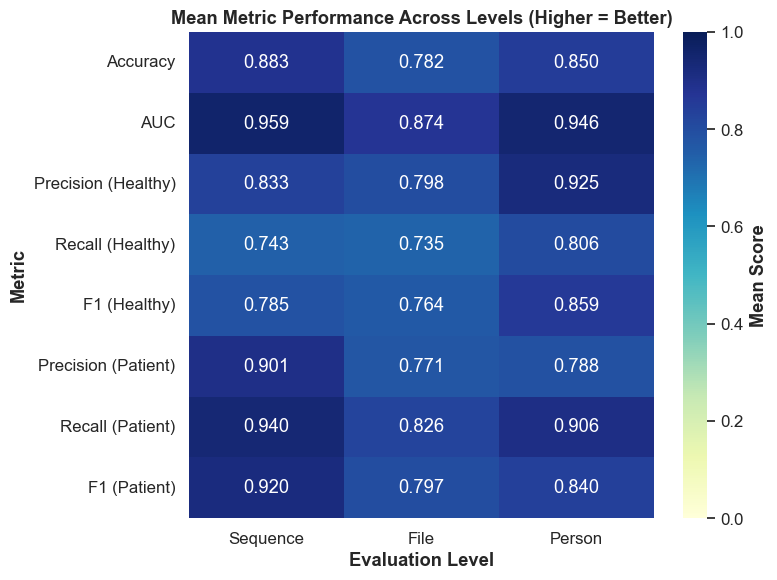

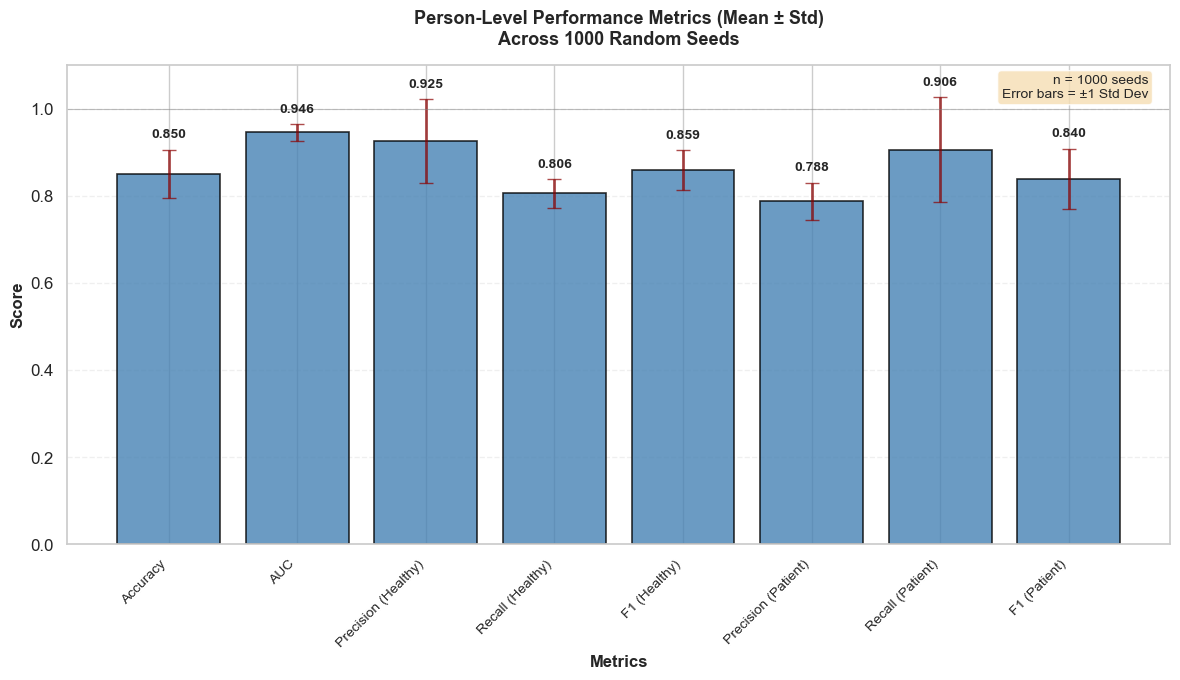


                                  PERSON-LEVEL ROBUSTNESS ANALYSIS                                  
                                 Analysis across 1000 random seeds                                  


                              TABLE 1: PERSON-LEVEL SUMMARY STATISTICS                              



,Metric,Value
0,Mean Accuracy,0.850222
1,Median Accuracy,0.888889
2,Std Deviation,0.056125
3,Min Accuracy,0.777778
4,Max Accuracy,1.000000
5,Range,0.222222
6,95% CI Lower,0.846739
7,95% CI Upper,0.853705
8,CI Width,0.006966
9,Coefficient of Variation (%),6.6012%



                                TABLE 2: COMPREHENSIVE SEED-BY-SEED PERFORMANCE RANKING                                 
                            (Ranked by Composite Score: Average of All Person-Level Metrics)                            
                                     (Unique Composite Scores Only - No Duplicates)                                     


🏆 TOP 5 PERFORMING SEEDS (Best Overall Performance - Unique Composite Scores):
------------------------------------------------------------------------------------------------------------------------


,Display_Rank,Rank,Seed,Composite_Score,Accuracy,AUC,F1_Healthy,F1_Patient,Deviation_from_Mean,Z_Score
0,1,1,6945,1.0000,1.0000,1.0000,1.0000,1.0000,+0.1351,+2.5563
1,2,15,6586,0.9083,0.8889,1.0000,0.8889,0.8889,+0.0435,+0.8224
2,3,30,4469,0.9048,0.8889,1.0000,0.9091,0.8571,+0.0399,+0.7557
3,4,39,7393,0.9021,0.8889,0.9500,0.8889,0.8889,+0.0372,+0.7041
4,5,560,4187,0.8986,0.8889,0.9500,0.9091,0.8571,+0.0337,+0.6374



⚠️ BOTTOM 5 PERFORMING SEEDS (Poorest Overall Performance - Unique Composite Scores):
------------------------------------------------------------------------------------------------------------------------


,Display_Rank,Rank,Seed,Composite_Score,Accuracy,AUC,F1_Healthy,F1_Patient,Deviation_from_Mean,Z_Score
0,1,1000,4738,0.7847,0.7778,0.8500,0.8000,0.7500,-0.0801,-1.5158
1,2,958,4262,0.7910,0.7778,0.9000,0.8000,0.7500,-0.0739,-1.3976
2,3,639,4001,0.7972,0.7778,0.9500,0.8000,0.7500,-0.0676,-1.2794
3,4,565,4080,0.8958,0.8889,0.9000,0.8889,0.8889,+0.0310,+0.5859
4,5,560,4187,0.8986,0.8889,0.9500,0.9091,0.8571,+0.0337,+0.6374



                             PERSON-LEVEL ROBUSTNESS ANALYSIS COMPLETE                              

✅ Analysis Summary:
   • Seeds analyzed: 1000
   • Mean accuracy: 0.850222
   • Std deviation: 0.056125
   • CV: 6.60% (Good (Stable))
   • 95% CI: [0.846739, 0.853705]
   • Range: [0.777778, 1.000000]




In [12]:
# =====================================
# MEAN METRIC PERFORMANCE VISUALIZATION
# =====================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Define metrics to analyze
metrics_keys = {
    "Accuracy": "accuracy",
    "AUC": "auc",
    "Precision (Healthy)": "precision_0",
    "Recall (Healthy)": "recall_0",
    "F1 (Healthy)": "f1_0",
    "Precision (Patient)": "precision_1",
    "Recall (Patient)": "recall_1",
    "F1 (Patient)": "f1_1"
}

levels = ['sequence', 'file', 'person']

# -------------------------------------------------------
# Mean Metric Performance Heatmap
# -------------------------------------------------------
mean_data = []

for metric_name, metric_key in metrics_keys.items():
    row = []
    for level_name in levels:
        values = [r[level_name][metric_key] for r in all_results]
        row.append(np.mean(values))
    mean_data.append(row)

mean_matrix = pd.DataFrame(mean_data, columns=[l.capitalize() for l in levels], index=list(metrics_keys.keys()))

plt.figure(figsize=(8, 6))
sns.heatmap(mean_matrix, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, cbar_kws={"label": "Mean Score"})
plt.title("Mean Metric Performance Across Levels (Higher = Better)")
plt.xlabel("Evaluation Level")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Person-Level Metrics Bar Chart
# -------------------------------------------------------

# Extract person-level metrics and calculate mean and std across all seeds
person_metrics = {}
for metric_name, metric_key in metrics_keys.items():
    values = [r['person'][metric_key] for r in all_results]
    person_metrics[metric_name] = {
        'mean': np.mean(values),
        'std': np.std(values)
    }

# Prepare data for plotting
metric_names = list(person_metrics.keys())
means = [person_metrics[m]['mean'] for m in metric_names]
stds = [person_metrics[m]['std'] for m in metric_names]

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(metric_names))
bars = ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.8, 
              color='steelblue', edgecolor='black', linewidth=1.2,
              error_kw={'linewidth': 2, 'ecolor': 'darkred', 'alpha': 0.7})

# Add value labels on top of bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Person-Level Performance Metrics (Mean ± Std)\nAcross {len(SEEDS)} Random Seeds', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names, rotation=45, ha='right', fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.axhline(y=1.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# Add legend
legend_text = f'n = {len(SEEDS)} seeds\nError bars = ±1 Std Dev'
ax.text(0.98, 0.98, legend_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# =====================================
# PERSON-LEVEL ROBUSTNESS ANALYSIS
# =====================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

# -------------------------------------------------------
# 1️⃣ EXTRACT PERSON-LEVEL ACCURACY DATA
# -------------------------------------------------------

# Build a DataFrame: Person ID × Seed → Accuracy
person_accuracies = []

for result in all_results:
    seed = result['seed']
    accuracy = result['person']['accuracy']
    person_accuracies.append({
        'seed': seed,
        'accuracy': accuracy
    })

df_person_acc = pd.DataFrame(person_accuracies)

print(f"\n{'='*100}")
print(f"{'PERSON-LEVEL ROBUSTNESS ANALYSIS':^100}")
print(f"{f'Analysis across {len(SEEDS)} random seeds':^100}")
print(f"{'='*100}\n")

# -------------------------------------------------------
# 2️⃣ COMPUTE SUMMARY STATISTICS
# -------------------------------------------------------

# Overall statistics
mean_acc = df_person_acc['accuracy'].mean()
std_acc = df_person_acc['accuracy'].std()
min_acc = df_person_acc['accuracy'].min()
max_acc = df_person_acc['accuracy'].max()
median_acc = df_person_acc['accuracy'].median()

# 95% Confidence Interval
confidence_level = 0.95
degrees_freedom = len(df_person_acc) - 1
confidence_interval = stats.t.interval(
    confidence_level,
    degrees_freedom,
    loc=mean_acc,
    scale=stats.sem(df_person_acc['accuracy'])
)

# Coefficient of Variation (CV%)
cv_percent = (std_acc / mean_acc) * 100 if mean_acc > 0 else 0

# Stability category based on CV%
if cv_percent < 5:
    stability_category = "Excellent (Very Stable)"
elif cv_percent < 10:
    stability_category = "Good (Stable)"
elif cv_percent < 15:
    stability_category = "Moderate (Acceptable)"
else:
    stability_category = "Poor (Unstable)"

# -------------------------------------------------------
# 3️⃣ TABLE 1: SUMMARY STATISTICS
# -------------------------------------------------------

summary_stats = pd.DataFrame({
    'Metric': [
        'Mean Accuracy',
        'Median Accuracy',
        'Std Deviation',
        'Min Accuracy',
        'Max Accuracy',
        'Range',
        '95% CI Lower',
        '95% CI Upper',
        'CI Width',
        'Coefficient of Variation (%)',
        'Stability Category',
        'Number of Seeds'
    ],
    'Value': [
        f"{mean_acc:.6f}",
        f"{median_acc:.6f}",
        f"{std_acc:.6f}",
        f"{min_acc:.6f}",
        f"{max_acc:.6f}",
        f"{max_acc - min_acc:.6f}",
        f"{confidence_interval[0]:.6f}",
        f"{confidence_interval[1]:.6f}",
        f"{confidence_interval[1] - confidence_interval[0]:.6f}",
        f"{cv_percent:.4f}%",
        stability_category,
        str(len(SEEDS))
    ]
})

print("\n" + "="*100)
print(f"{'TABLE 1: PERSON-LEVEL SUMMARY STATISTICS':^100}")
print("="*100 + "\n")
display(summary_stats)

# -------------------------------------------------------
# 4️⃣ TABLE 2: DETAILED SEED-BY-SEED BREAKDOWN (ALL METRICS)
# -------------------------------------------------------

# Extract all person-level metrics for each seed
seed_breakdown_data = []
for result in all_results:
    seed_breakdown_data.append({
        'Seed': result['seed'],
        'Accuracy': result['person']['accuracy'],
        'AUC': result['person']['auc'],
        'Precision_Healthy': result['person']['precision_0'],
        'Recall_Healthy': result['person']['recall_0'],
        'F1_Healthy': result['person']['f1_0'],
        'Precision_Patient': result['person']['precision_1'],
        'Recall_Patient': result['person']['recall_1'],
        'F1_Patient': result['person']['f1_1']
    })

seed_breakdown = pd.DataFrame(seed_breakdown_data)

# Calculate composite score (average of all metrics)
metric_cols = ['Accuracy', 'AUC', 'Precision_Healthy', 'Recall_Healthy', 'F1_Healthy',
               'Precision_Patient', 'Recall_Patient', 'F1_Patient']
seed_breakdown['Composite_Score'] = seed_breakdown[metric_cols].mean(axis=1)

# Calculate deviation and z-score based on composite score
mean_composite = seed_breakdown['Composite_Score'].mean()
std_composite = seed_breakdown['Composite_Score'].std()
seed_breakdown['Deviation_from_Mean'] = seed_breakdown['Composite_Score'] - mean_composite
seed_breakdown['Z_Score'] = (seed_breakdown['Composite_Score'] - mean_composite) / std_composite if std_composite > 0 else 0

# Rank seeds by composite score
seed_breakdown['Rank'] = seed_breakdown['Composite_Score'].rank(ascending=False, method='min').astype(int)
seed_breakdown = seed_breakdown.sort_values('Rank').reset_index(drop=True)

print("\n" + "="*120)
print(f"{'TABLE 2: COMPREHENSIVE SEED-BY-SEED PERFORMANCE RANKING':^120}")
print(f"{'(Ranked by Composite Score: Average of All Person-Level Metrics)':^120}")
print(f"{'(Unique Composite Scores Only - No Duplicates)':^120}")
print("="*120 + "\n")

# Round Composite_Score to 4 decimals for comparison
seed_breakdown['Composite_Score_Rounded'] = seed_breakdown['Composite_Score'].round(4)

# Sort by Composite_Score descending (best to worst)
seed_breakdown_sorted = seed_breakdown.sort_values('Composite_Score', ascending=False).reset_index(drop=True)

# Remove duplicates based on rounded Composite_Score, keeping first occurrence
seed_breakdown_unique = seed_breakdown_sorted.drop_duplicates(subset='Composite_Score_Rounded', keep='first')

# Get top 5 unique performers (highest composite scores)
top_5 = seed_breakdown_unique.head(5)[['Rank', 'Seed', 'Composite_Score', 'Accuracy', 'AUC', 
                                        'F1_Healthy', 'F1_Patient', 'Deviation_from_Mean', 'Z_Score']].copy()

# Get bottom 5 unique performers (lowest composite scores)
bottom_5 = seed_breakdown_unique.tail(5)[['Rank', 'Seed', 'Composite_Score', 'Accuracy', 'AUC', 
                                           'F1_Healthy', 'F1_Patient', 'Deviation_from_Mean', 'Z_Score']].copy()

# Sort for display
top_5 = top_5.sort_values('Composite_Score', ascending=False).reset_index(drop=True)
bottom_5 = bottom_5.sort_values('Composite_Score', ascending=True).reset_index(drop=True)

# Add display rank (1-5)
top_5.insert(0, 'Display_Rank', range(1, len(top_5) + 1))
bottom_5.insert(0, 'Display_Rank', range(1, len(bottom_5) + 1))

print("\n🏆 TOP 5 PERFORMING SEEDS (Best Overall Performance - Unique Composite Scores):")
print("-" * 120)
display(top_5.style.format({
    'Composite_Score': '{:.4f}',
    'Accuracy': '{:.4f}',
    'AUC': '{:.4f}',
    'F1_Healthy': '{:.4f}',
    'F1_Patient': '{:.4f}',
    'Deviation_from_Mean': '{:+.4f}',
    'Z_Score': '{:+.4f}'
}).background_gradient(subset=['Composite_Score'], cmap='Greens'))

print("\n⚠️ BOTTOM 5 PERFORMING SEEDS (Poorest Overall Performance - Unique Composite Scores):")
print("-" * 120)
display(bottom_5.style.format({
    'Composite_Score': '{:.4f}',
    'Accuracy': '{:.4f}',
    'AUC': '{:.4f}',
    'F1_Healthy': '{:.4f}',
    'F1_Patient': '{:.4f}',
    'Deviation_from_Mean': '{:+.4f}',
    'Z_Score': '{:+.4f}'
}).background_gradient(subset=['Composite_Score'], cmap='Reds_r'))

# -------------------------------------------------------
# FINAL SUMMARY
# -------------------------------------------------------

print("\n" + "="*100)
print(f"{'PERSON-LEVEL ROBUSTNESS ANALYSIS COMPLETE':^100}")
print("="*100)
print(f"\n✅ Analysis Summary:")
print(f"   • Seeds analyzed: {len(SEEDS)}")
print(f"   • Mean accuracy: {mean_acc:.6f}")
print(f"   • Std deviation: {std_acc:.6f}")
print(f"   • CV: {cv_percent:.2f}% ({stability_category})")
print(f"   • 95% CI: [{confidence_interval[0]:.6f}, {confidence_interval[1]:.6f}]")
print(f"   • Range: [{min_acc:.6f}, {max_acc:.6f}]")
print(f"\n" + "="*100 + "\n")
